# IY013 -- Pairwise (one-vs-one) Classification Results: 12-class new dataset

**Goal:** Visualise the pairwise Raw SVM / LSTM / Transformer sweep produced by
`IY013_tf_condition_pairwise_new.py` (all 66 pairs of the 12 fixed new-dataset TFs --
TF identity only, conditions pooled -- on both Steady-state and Full variants).

This notebook only loads and plots `IY013_tf_condition_pairwise_new_results.csv`; it
does not retrain anything. Run `IY013_tf_condition_pairwise_new.py` first (it is
resumable, so it is safe to leave running via e.g. `nohup`).

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

IY013_DIR = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY013")

sys.path.insert(0, str(Path("/home/ianyang/stochastic_simulations/src").resolve()))
sys.path.insert(0, str(IY013_DIR))
from IY013_pairwise_heatmaps import plot_pairwise_heatmaps, plot_pairwise_summary

plt.rcParams.update({
    "font.family": "sans-serif", "axes.titlesize": 14,
    "axes.labelsize": 12, "xtick.labelsize": 10,
    "ytick.labelsize": 10, "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="colorblind")

In [2]:
RESULTS_CSV = IY013_DIR / "IY013_tf_condition_pairwise_new_results.csv"
results_df = pd.read_csv(RESULTS_CSV)

# Fixed 12-class selection: TF identity only (conditions pooled), IY021 sanity-check panel
# (same set as IY013_tf_condition_pairwise_new.py; sorted for canonical matrix indexing)
CLASSES = sorted({"Opi1", "Msn2", "Yox1", "Tea1", "Rox1", "Sok2",
                   "Cup9", "Spt15", "Cbf1", "Stb5", "Cin5", "Rsc3"})
VARIANTS = ["Steady-state", "Full"]
CLASSIFIERS = ["Raw SVM", "LSTM", "Transformer"]

n_pairs_expected = len(CLASSES) * (len(CLASSES) - 1) // 2
n_expected = n_pairs_expected * len(VARIANTS) * len(CLASSIFIERS)
print(f"Loaded {len(results_df)} / {n_expected} expected rows "
      f"({n_pairs_expected} pairs x {len(VARIANTS)} variants x {len(CLASSIFIERS)} classifiers)")
results_df.head()

Loaded 396 / 396 expected rows (66 pairs x 2 variants x 3 classifiers)


,Class_A,Class_B,Dataset,Classifier,Accuracy,N_train,N_test
0,Cbf1,Cin5,Steady-state,Raw SVM,0.563636,440,110
1,Cbf1,Cin5,Steady-state,LSTM,0.545455,440,110
2,Cbf1,Cin5,Steady-state,Transformer,0.590909,440,110
3,Cbf1,Cin5,Full,Raw SVM,0.572727,440,110
4,Cbf1,Cin5,Full,LSTM,0.600000,440,110


## Pairwise accuracy heatmaps

One heatmap per (dataset variant, classifier); cell = held-out test accuracy for that
TF pair. Diagonal is masked (no self-pair). Chance level for every pair is 0.5.

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-25-IY013/IY013_tf_condition_pairwise_new_heatmaps.png


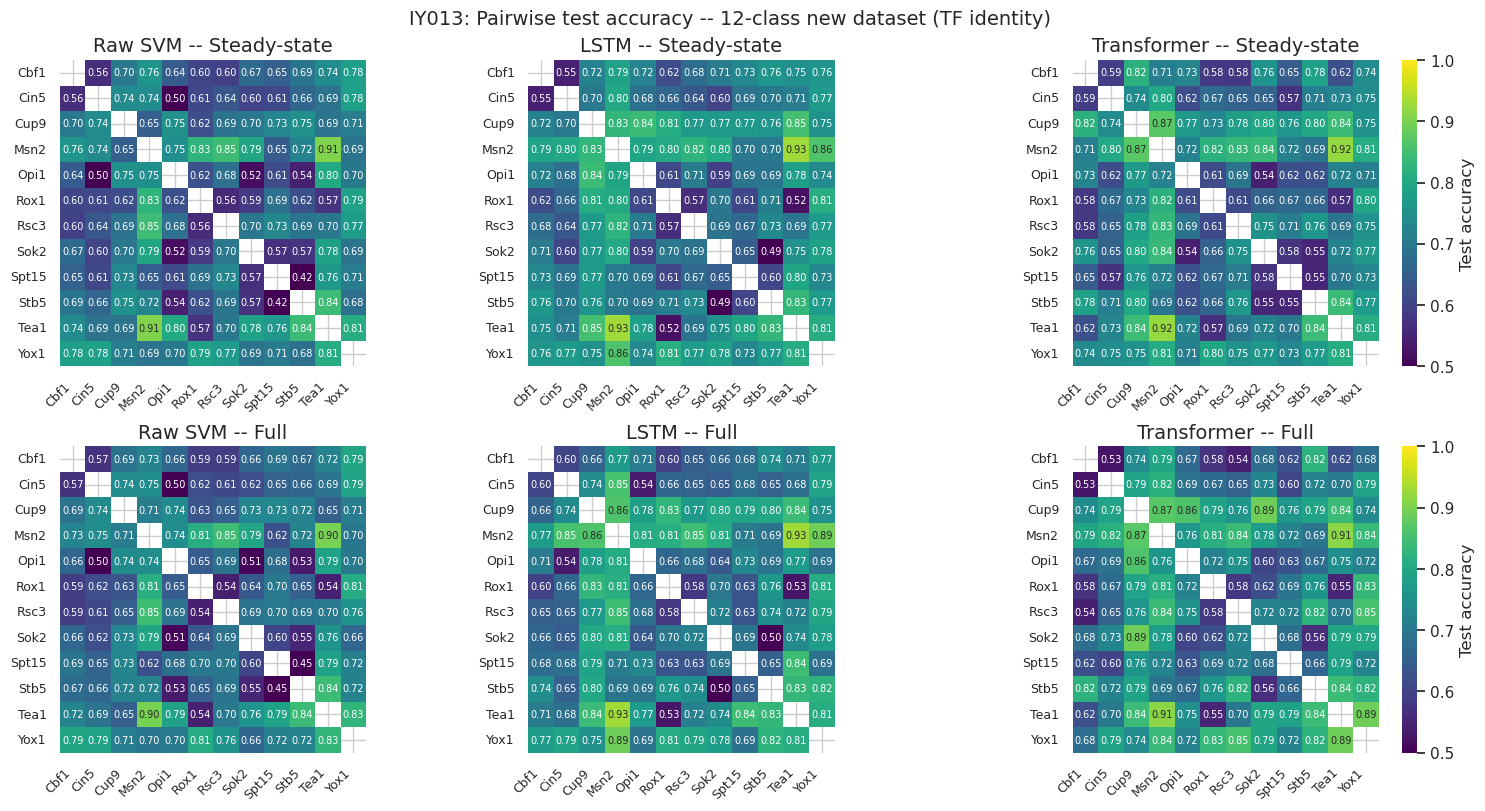

In [3]:
fig_path = IY013_DIR / "IY013_tf_condition_pairwise_new_heatmaps.png"
_ = plot_pairwise_heatmaps(
    results_df, CLASSES, VARIANTS, CLASSIFIERS,
    title="IY013: Pairwise test accuracy -- 12-class new dataset (TF identity)",
    fig_path=fig_path, annot_fontsize=7,
)
plt.show()

## Summary: mean pairwise accuracy per classifier

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-25-IY013/IY013_tf_condition_pairwise_new_summary.png


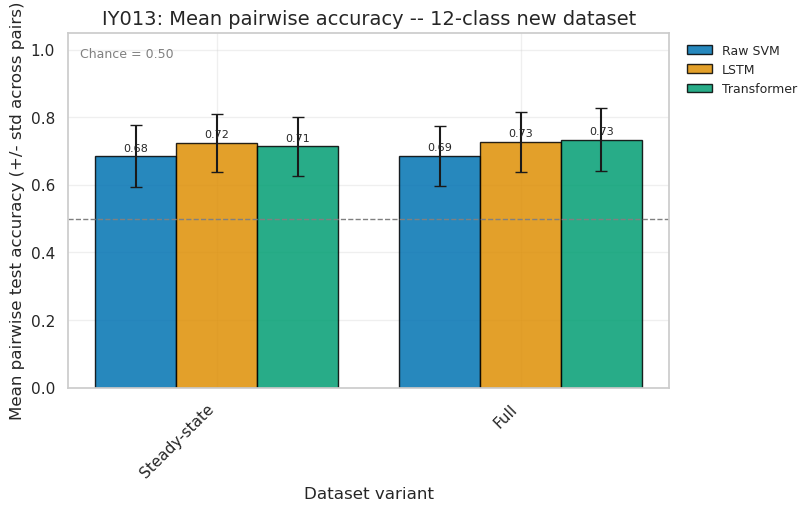

In [4]:
fig_path = IY013_DIR / "IY013_tf_condition_pairwise_new_summary.png"
_ = plot_pairwise_summary(
    results_df, VARIANTS, CLASSIFIERS,
    title="IY013: Mean pairwise accuracy -- 12-class new dataset",
    fig_path=fig_path,
)
plt.show()

## Hardest-to-distinguish pairs

Lowest mean accuracy (averaged across the 3 classifiers) per (variant, pair) --
i.e. the TF pairs that are most confusable.

In [5]:
pair_means = (
    results_df.groupby(["Dataset", "Class_A", "Class_B"])["Accuracy"]
    .mean()
    .reset_index()
    .sort_values("Accuracy")
)
pair_means.head(10)

,Dataset,Class_A,Class_B,Accuracy
126,Steady-state,Spt15,Stb5,0.524752
57,Full,Sok2,Stb5,0.537954
123,Steady-state,Sok2,Stb5,0.537954
49,Full,Rox1,Tea1,0.540682
106,Steady-state,Opi1,Sok2,0.551724
115,Steady-state,Rox1,Tea1,0.553806
0,Full,Cbf1,Cin5,0.566667
66,Steady-state,Cbf1,Cin5,0.566667
45,Full,Rox1,Rsc3,0.568627
13,Full,Cin5,Opi1,0.575758
